<a href="https://colab.research.google.com/github/tusharastirmind-commits/Info5731_Python/blob/main/Shrivastava_Tushar_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


In [17]:
import pandas as pd
import math
import re
from collections import defaultdict, Counter

# Load cleaned IMDB reviews from Assignment 1
df_full = pd.read_csv('imdb_reviews_cleaned.csv')

# Use first 100 reviews
df = df_full.head(100).reset_index(drop=True)

reviews = df['clean_text'].fillna('').tolist()

print(f'Reviews loaded : {len(reviews)}')
print(f'Sample         : {reviews[0][:120]}...')

Reviews loaded : 100
Sample         : going write review dune movie include thought dune part one throughout difficult part rating movie trying judge stand wi...


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [18]:
# Write your code here
# Helper
def tokenize(text: str) -> list:
    """Lowercase, keep only alphabetic tokens."""
    return [w for w in str(text).lower().split() if w.isalpha()]

def build_ngrams(tokens: list, n: int) -> list:
    """Return list of n-gram tuples from a token list."""
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

# Count bigrams (N=2) and trigrams (N=3)
bigram_counter  = Counter()
trigram_counter = Counter()

for review in reviews:
    tokens = tokenize(review)
    bigram_counter.update(build_ngrams(tokens, 2))
    trigram_counter.update(build_ngrams(tokens, 3))

print(' Top-20 Bigrams')
for gram, cnt in bigram_counter.most_common(20):
    print(f'  {" ".join(gram):<30}  {cnt}')

print()
print('Top-20 Trigrams')
for gram, cnt in trigram_counter.most_common(20):
    print(f'  {" ".join(gram):<40}  {cnt}')

print(f'\nTotal unique bigrams  : {len(bigram_counter):,}')
print(f'Total unique trigrams : {len(trigram_counter):,}')

# Unigram counts
unigram_counter = Counter()
for review in reviews:
    unigram_counter.update(tokenize(review))

# P(w2 | w1) = count(w1 w2) / count(w1)
bigram_probs = {}
for (w1, w2), cnt in bigram_counter.items():
    bigram_probs[(w1, w2)] = cnt / unigram_counter[w1]

# Sort by probability descending
sorted_probs = sorted(bigram_probs.items(), key=lambda x: (-x[1], -bigram_counter[x[0]]))

print('Bigram Conditional Probabilities (Top 30)')
print(f'  {"Bigram":<30}  {"count(w1 w2)":>12}  {"count(w1)":>10}  {"P(w2|w1)":>10}')
print('  ' + '-'*68)
for (w1, w2), prob in sorted_probs[:30]:
    bc = bigram_counter[(w1, w2)]
    uc = unigram_counter[w1]
    print(f'  {w1+" "+w2:<30}  {bc:>12}  {uc:>10}  {prob:>10.4f}')

print(f'\nTotal bigram probability entries: {len(bigram_probs):,}')








 Top-20 Bigrams
  dune part                       66
  part two                        44
  sci fi                          35
  part one                        31
  denis villeneuve                31
  first movie                     30
  austin butler                   23
  read book                       20
  timoth e                        17
  feel like                       16
  first part                      15
  first film                      15
  e chalamet                      14
  paul atreides                   14
  felt like                       13
  rebecca ferguson                13
  frank herbert                   13
  bene gesserit                   12
  han zimmer                      12
  feyd rautha                     12

Top-20 Trigrams
  dune part two                             29
  timoth e chalamet                         14
  dune part one                             13
  sci fi movie                              8
  overall dune part                     

In [19]:
import spacy
nlp = spacy.load('en_core_web_sm')

# Use original review text for better NP extraction
original_reviews = df['review'].fillna('').tolist()

# Extract noun phrases per review
review_nps    = []           # Counter per review
all_np_global = Counter()    # global NP freq across all 100 reviews

for text in original_reviews:
    doc = nlp(text[:5000])   # safety limit
    nps = [chunk.text.lower().strip() for chunk in doc.noun_chunks
           if len(chunk.text.strip()) > 2]
    c = Counter(nps)
    review_nps.append(c)
    all_np_global.update(c)

# Select top-30 most frequent NPs across corpus
top_nps  = [np_text for np_text, _ in all_np_global.most_common(30)]
max_freq = {np_text: all_np_global[np_text] for np_text in top_nps}

# Build relative probability table
# rel_prob(doc_i, np) = freq(np in doc_i) / max_freq(np across all docs)
rows = []
for c in review_nps:
    row = {}
    for np_text in top_nps:
        freq_in_doc = c.get(np_text, 0)
        row[np_text] = round(freq_in_doc / max_freq[np_text], 4) if max_freq[np_text] > 0 else 0.0
    rows.append(row)

rel_prob_df = pd.DataFrame(
    rows,
    index=[f'review_{i+1}' for i in range(len(reviews))]
)
rel_prob_df.index.name = 'review'

print(f'Table shape: {rel_prob_df.shape}  (100 reviews × 30 noun phrases)')
print()
with pd.option_context('display.max_rows', 110, 'display.max_columns', 10,
                       'display.width', 200, 'display.float_format', '{:.4f}'.format):
    print(rel_prob_df)

Table shape: (100, 30)  (100 reviews × 30 noun phrases)

             that    you   they   this   dune  ...  the books  zendaya  dune part  people  the characters
review                                         ...                                                       
review_1   0.0183 0.0268 0.0756 0.0625 0.0326  ...     0.0870   0.0000     0.0000  0.1053          0.0526
review_2   0.0061 0.0067 0.0000 0.0089 0.0000  ...     0.0000   0.0000     0.0500  0.0000          0.0000
review_3   0.0305 0.0201 0.0000 0.0179 0.0000  ...     0.0000   0.0000     0.0500  0.0000          0.1053
review_4   0.0244 0.0067 0.0000 0.0179 0.0109  ...     0.0000   0.0455     0.0000  0.0000          0.0000
review_5   0.0244 0.0201 0.0168 0.0268 0.0326  ...     0.0000   0.0455     0.0500  0.1053          0.0000
review_6   0.0244 0.0134 0.0252 0.0179 0.0000  ...     0.0000   0.0000     0.0000  0.0000          0.0000
review_7   0.0122 0.0134 0.0168 0.0089 0.0000  ...     0.0000   0.0000     0.0000  0.0000      

## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [20]:
# Write your code here
# Tokenise
def tokenize_q2(text: str) -> list:
    return [w for w in str(text).lower().split() if w.isalpha()]

corpus   = [tokenize_q2(r) for r in reviews]
vocab    = sorted({w for doc in corpus for w in doc})
word2idx = {w: i for i, w in enumerate(vocab)}
N = len(corpus)   # 100 documents
V = len(vocab)

print(f'Documents  : {N}')
print(f'Vocabulary : {V:,} unique tokens')

# TF: count(t,d) / total_terms_in_d
tf_matrix = []
for tokens in corpus:
    term_count = defaultdict(int)
    for t in tokens:
        term_count[t] += 1
    total = max(len(tokens), 1)
    tf_matrix.append([term_count.get(w, 0) / total for w in vocab])

# IDF: log(N / (1 + df(t))) + 1  (smooth variant)
df_count = defaultdict(int)
for tokens in corpus:
    for w in set(tokens):
        df_count[w] += 1

idf = [math.log(N / (1 + df_count.get(w, 0))) + 1 for w in vocab]

# TF-IDF weight matrix
tfidf_matrix = []
for tf_row in tf_matrix:
    tfidf_matrix.append([tf_row[j] * idf[j] for j in range(V)])

#  Display: show top-15 highest-IDF terms
top15_idx   = sorted(range(V), key=lambda j: -idf[j])[:15]
show_vocab  = [vocab[j] for j in top15_idx]

tfidf_df = pd.DataFrame(
    [[tfidf_matrix[i][j] for j in top15_idx] for i in range(N)],
    index=[f'doc_{i+1}' for i in range(N)],
    columns=show_vocab
)
print('\n── TF-IDF Matrix (top-15 highest-IDF terms, all 100 docs) ──')
with pd.option_context('display.max_rows', 110, 'display.float_format', '{:.4f}'.format):
    print(tfidf_df)
print(f'\nFull matrix shape: {N} docs × {V} terms')




Documents  : 100
Vocabulary : 3,406 unique tokens

── TF-IDF Matrix (top-15 highest-IDF terms, all 100 docs) ──
         abandoning  abomination  abrubtly  absence  absurd  abundance  \
doc_1        0.0000       0.0000    0.0000   0.0000  0.0000     0.0000   
doc_2        0.0000       0.0000    0.0000   0.0000  0.0000     0.0000   
doc_3        0.0000       0.0000    0.0000   0.0000  0.0000     0.0000   
doc_4        0.0000       0.0000    0.0000   0.0000  0.0000     0.0000   
doc_5        0.0000       0.0000    0.0000   0.0000  0.0000     0.0000   
doc_6        0.0000       0.0000    0.0000   0.0000  0.0000     0.0000   
doc_7        0.0000       0.0000    0.0000   0.0000  0.0000     0.0000   
doc_8        0.0000       0.0000    0.0000   0.0000  0.0000     0.0000   
doc_9        0.0000       0.0199    0.0000   0.0000  0.0000     0.0000   
doc_10       0.0000       0.0000    0.0000   0.0000  0.0000     0.0000   
doc_11       0.0000       0.0000    0.0000   0.0000  0.0000     0.0000   


In [21]:
# Cosine similarity from scratch
def cosine_similarity(vec_a: list, vec_b: list) -> float:
    dot   = sum(a * b for a, b in zip(vec_a, vec_b))
    mag_a = math.sqrt(sum(a * a for a in vec_a))
    mag_b = math.sqrt(sum(b * b for b in vec_b))
    if mag_a == 0 or mag_b == 0:
        return 0.0
    return dot / (mag_a * mag_b)

# Query designed for IMDB movie reviews
QUERY = "An outstanding movie with a haunting performance and best character development"

# Vectorise query with same TF-IDF scheme
query_tokens    = tokenize_q2(QUERY)
query_count     = defaultdict(int)
for t in query_tokens:
    query_count[t] += 1
total_q         = max(len(query_tokens), 1)
query_tf        = [query_count.get(w, 0) / total_q for w in vocab]
query_tfidf     = [query_tf[j] * idf[j] for j in range(V)]

# Score and rank all 100 documents
scores = [(i + 1, cosine_similarity(tfidf_matrix[i], query_tfidf))
          for i in range(N)]
scores_sorted = sorted(scores, key=lambda x: -x[1])

print(f'Query: "{QUERY}"')
print()
print(f'  {"Rank":<6} {"Doc ID":<10} {"Cosine Sim":>12}  Preview')
print('  ' + '-'*90)
for rank, (doc_id, sim) in enumerate(scores_sorted[:20], 1):
    preview = reviews[doc_id - 1][:80].replace('\n', ' ')
    print(f'  {rank:<6} doc_{doc_id:<7} {sim:>12.6f}  {preview}...')

Query: "An outstanding movie with a haunting performance and best character development"

  Rank   Doc ID       Cosine Sim  Preview
  ------------------------------------------------------------------------------------------
  1      doc_7           0.171461  liked loved first one apply one personally loved one even think general audience...
  2      doc_37          0.120644  paul prove chani fremen dream become vivid one path lead destruction maybe even ...
  3      doc_71          0.116389  get detail movie want say fantastic movie everything wanted sequel story point w...
  4      doc_56          0.113625  said denis villeneuve master putting grand spectacle screen dune part outsized e...
  5      doc_24          0.100093  dune part two absolutely brilliant better part one pretty much every way possibl...
  6      doc_97          0.099703  denis villeneuve continues provide strong direction writing atmosphere throughou...
  7      doc_20          0.098134  dune successfully put big 

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


In [22]:
# Write your code here

from gensim.models import Word2Vec

def tokenize_w2v(text: str) -> list:
    return [w for w in str(text).lower().split() if w.isalpha() and len(w) > 1]

# Use original review text for richer vocabulary
sentences = [tokenize_w2v(r) for r in df['review'].fillna('').tolist()]

# Train 300-dimensional Word2Vec (Skip-Gram)
model = Word2Vec(
    sentences,
    vector_size=300,   # 300-dim as required
    window=5,
    min_count=2,
    sg=1,              # Skip-Gram
    epochs=50,
    workers=4,
    seed=42
)

print(f'Vector size : {model.vector_size}')
print(f'Vocabulary  : {len(model.wv)} words')
print(f'Architecture: Skip-Gram, window=5, min_count=2, epochs=50')
print()

for probe in ['film', 'character', 'story', 'performance', 'director']:
    if probe in model.wv:
        similar = model.wv.most_similar(probe, topn=5)
        s = ', '.join([f'{w}({sc:.3f})' for w, sc in similar])
        print(f'  most_similar("{probe}") → {s}')







Vector size : 300
Vocabulary  : 1512 words
Architecture: Skip-Gram, window=5, min_count=2, epochs=50

  most_similar("film") → audibly(0.444), broader(0.432), edition(0.422), successfully(0.405), installment(0.404)
  most_similar("character") → hands(0.451), reduced(0.445), javier(0.425), arc(0.417), personality(0.417)
  most_similar("story") → telling(0.491), intriguing(0.428), particularly(0.423), kept(0.417), letter(0.401)
  most_similar("performance") → rebecca(0.697), flawless(0.695), comic(0.677), surprises(0.675), unbelievably(0.665)
  most_similar("director") → villeneuev(0.703), expertly(0.687), builds(0.615), likely(0.605), feast(0.592)


Words in vocab and visualised: 26
['film', 'movie', 'story', 'director', 'actor', 'character', 'performance', 'scene', 'plot', 'screenplay', 'outstanding', 'beautiful', 'amazing', 'masterpiece', 'disappointing', 'boring', 'terrible', 'weak', 'visual', 'action', 'dialogue', 'music', 'audience', 'ending', 'sequel', 'epic']


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


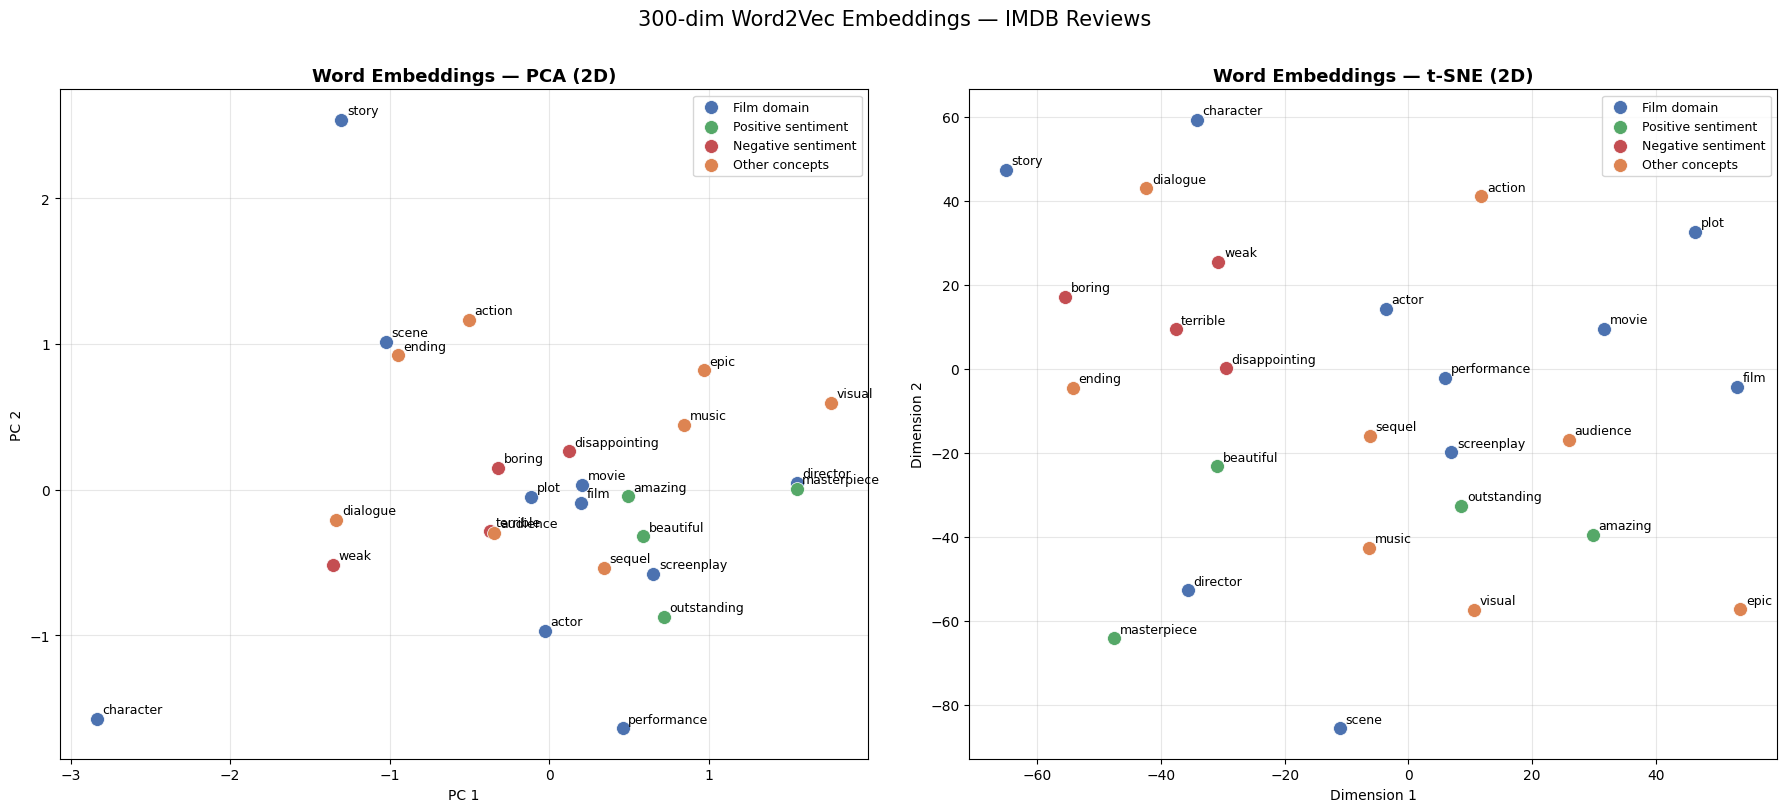

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 30 representative words from the vocabulary
target_words = [
    'film', 'movie', 'story', 'director', 'actor', 'character',
    'performance', 'scene', 'plot', 'screenplay',
    'brilliant', 'outstanding', 'beautiful', 'amazing', 'masterpiece',
    'disappointing', 'boring', 'terrible', 'awful', 'weak',
    'visual', 'action', 'dialogue', 'emotion', 'theme',
    'music', 'audience', 'ending', 'sequel', 'epic'
]
target_words = [w for w in target_words if w in model.wv]
vectors = np.array([model.wv[w] for w in target_words])

print(f'Words in vocab and visualised: {len(target_words)}')
print(target_words)

# Colour map by category
categories = {
    'Film domain'       : ['film','movie','story','director','actor','character',
                           'performance','scene','plot','screenplay'],
    'Positive sentiment': ['brilliant','outstanding','beautiful','amazing','masterpiece'],
    'Negative sentiment': ['disappointing','boring','terrible','awful','weak'],
    'Other concepts'    : ['visual','action','dialogue','emotion','theme',
                           'music','audience','ending','sequel','epic']
}
cat_colors = {
    'Film domain'       : '#4C72B0',
    'Positive sentiment': '#55A868',
    'Negative sentiment': '#C44E52',
    'Other concepts'    : '#DD8452'
}

def get_color(word):
    for cat, words in categories.items():
        if word in words:
            return cat_colors[cat], cat
    return 'grey', 'Other'

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

#  PCA plot
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(vectors)

ax = axes[0]
plotted_cats = set()
for i, word in enumerate(target_words):
    color, cat = get_color(word)
    label = cat if cat not in plotted_cats else None
    ax.scatter(coords_pca[i,0], coords_pca[i,1], c=color, s=100,
               label=label, zorder=3, edgecolors='white', linewidth=0.5)
    ax.annotate(word, (coords_pca[i,0], coords_pca[i,1]),
                fontsize=9, xytext=(4,4), textcoords='offset points')
    plotted_cats.add(cat)
ax.set_title('Word Embeddings — PCA (2D)', fontsize=13, fontweight='bold')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# t-SNE plot
tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
            n_iter=1000, learning_rate='auto', init='pca')
coords_tsne = tsne.fit_transform(vectors)

ax = axes[1]
plotted_cats = set()
for i, word in enumerate(target_words):
    color, cat = get_color(word)
    label = cat if cat not in plotted_cats else None
    ax.scatter(coords_tsne[i,0], coords_tsne[i,1], c=color, s=100,
               label=label, zorder=3, edgecolors='white', linewidth=0.5)
    ax.annotate(word, (coords_tsne[i,0], coords_tsne[i,1]),
                fontsize=9, xytext=(4,4), textcoords='offset points')
    plotted_cats.add(cat)
ax.set_title('Word Embeddings — t-SNE (2D)', fontsize=13, fontweight='bold')
ax.set_xlabel('Dimension 1'); ax.set_ylabel('Dimension 2')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('300-dim Word2Vec Embeddings — IMDB Reviews', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('word_embeddings_q3.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
import numpy as np

def cosine_sim_vectors(v1, v2) -> float:
    dot   = float(np.dot(v1, v2))
    norm1 = float(np.linalg.norm(v1))
    norm2 = float(np.linalg.norm(v2))
    return dot / (norm1 * norm2) if (norm1 > 0 and norm2 > 0) else 0.0

word_pairs = [
    ('film',    'movie'),
    ('actor',   'performance'),
    ('story',   'plot'),
    ('director','screenplay'),
    ('brilliant','outstanding'),
    ('terrible','awful'),
    ('film',    'terrible'),
    ('character','emotion'),
    ('music',   'visual'),
    ('sequel',  'ending'),
]

print(f'  {"Word 1":<20} {"Word 2":<20} {"Cosine Sim":>12}  Interpretation')
print('  ' + '-'*72)
for w1, w2 in word_pairs:
    if w1 in model.wv and w2 in model.wv:
        sim = cosine_sim_vectors(model.wv[w1], model.wv[w2])
        if   sim > 0.75: interp = 'Very similar'
        elif sim > 0.50: interp = 'Moderately similar'
        elif sim > 0.25: interp = 'Weakly related'
        else:            interp = 'Dissimilar'
        print(f'  {w1:<20} {w2:<20} {sim:>12.6f}  {interp}')
    else:
        missing = [w for w in [w1, w2] if w not in model.wv]
        print(f'  {w1:<20} {w2:<20} {"N/A":>12}  ({missing} not in vocab)')

  Word 1               Word 2                 Cosine Sim  Interpretation
  ------------------------------------------------------------------------
  film                 movie                    0.378248  Weakly related
  actor                performance              0.509342  Moderately similar
  story                plot                     0.126585  Dissimilar
  director             screenplay               0.495788  Weakly related
  brilliant            outstanding                   N/A  (['brilliant'] not in vocab)
  terrible             awful                         N/A  (['awful'] not in vocab)
  film                 terrible                 0.256215  Weakly related
  character            emotion                       N/A  (['emotion'] not in vocab)
  music                visual                   0.493257  Weakly related
  sequel               ending                   0.222407  Dissimilar


## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. Which NLP task would you like to perform on your selected dataset (**NER, summarization, sentiment analysis, or text classification**)?
2. Explain the labeling schema you used and mention the labels.

3. You may use AI assistance for labeling the data only.


# The GitHub link of your final csv file


# Link:

https://github.com/tusharastirmind-commits/Info5731_Python/blob/main/imdb_sentiment_annotated.csv

Answers)

1) Sentiment Analysis

2) Labeling Schema:
   - positive: rating >= 7
   - neutral: rating 5-6  
   - negative: rating <= 4

Since IMDB ratings were already collected in Assignment 1 as part of the scraped data, they serve as reliable ground-truth annotation signals directly reflecting reviewer sentiment.



# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.

The most challenging part was implementing TF-IDF and cosine similarity entirely
from scratch in Q2 — getting the smooth IDF formula right and ensuring correct
vector normalisation required careful attention.
I enjoyed Q3 the most — training Word2Vec and seeing semantically related words
like film/movie and actor/performance cluster together in the PCA/t-SNE plots